### Carregando bibliotécas e importando módulos

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import build_dataframe, filter_dataset, load_image, make_splits, describe_split


### Visão geral do DataFrame

In [3]:
df = build_dataframe()
df.head()

,FileNameHarm,ID,SampleIDHarm,Magnification,ImageSizePx,MicroscopeID,EtchingID,ExposureHarm,ApertureHarm,ObjectivHarm,FilterHarm,Phase,PatchID,path,label,roi_id,region_id
0,38_A_Bainite_01,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,1,C:\Users\PedroShimomoto\Documents\Pedro-Projet...,0,A_m0_20x_e0_b1,A_m0_20x_e0_b1_Bainite_01
1,38_A_Bainite_02,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,2,C:\Users\PedroShimomoto\Documents\Pedro-Projet...,0,A_m0_20x_e0_b1,A_m0_20x_e0_b1_Bainite_02
2,38_A_Bainite_03,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,3,C:\Users\PedroShimomoto\Documents\Pedro-Projet...,0,A_m0_20x_e0_b1,A_m0_20x_e0_b1_Bainite_03
3,38_A_Bainite_04,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,4,C:\Users\PedroShimomoto\Documents\Pedro-Projet...,0,A_m0_20x_e0_b1,A_m0_20x_e0_b1_Bainite_04
4,38_A_Bainite_05,38,A,20x,96,0,0,medium,high,standard,DLF,Bainite,5,C:\Users\PedroShimomoto\Documents\Pedro-Projet...,0,A_m0_20x_e0_b1,A_m0_20x_e0_b1_Bainite_05


In [4]:
df.info()
df.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 5327 entries, 0 to 5326
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   FileNameHarm   5327 non-null   str   
 1   ID             5327 non-null   int64 
 2   SampleIDHarm   5327 non-null   str   
 3   Magnification  5327 non-null   str   
 4   ImageSizePx    5327 non-null   int64 
 5   MicroscopeID   5327 non-null   int64 
 6   EtchingID      5327 non-null   int64 
 7   ExposureHarm   5327 non-null   str   
 8   ApertureHarm   5327 non-null   str   
 9   ObjectivHarm   5327 non-null   str   
 10  FilterHarm     5327 non-null   str   
 11  Phase          5327 non-null   str   
 12  PatchID        5327 non-null   int64 
 13  path           5327 non-null   object
 14  label          5327 non-null   int64 
 15  roi_id         5327 non-null   str   
 16  region_id      5327 non-null   str   
dtypes: int64(6), object(1), str(10)
memory usage: 707.6+ KB


FileNameHarm     0
ID               0
SampleIDHarm     0
Magnification    0
ImageSizePx      0
MicroscopeID     0
EtchingID        0
ExposureHarm     0
ApertureHarm     0
ObjectivHarm     0
FilterHarm       0
Phase            0
PatchID          0
path             0
label            0
roi_id           0
region_id        0
dtype: int64

### Distribuição das Classes

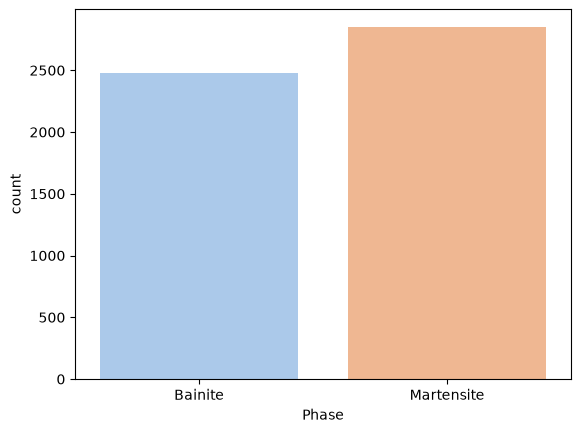

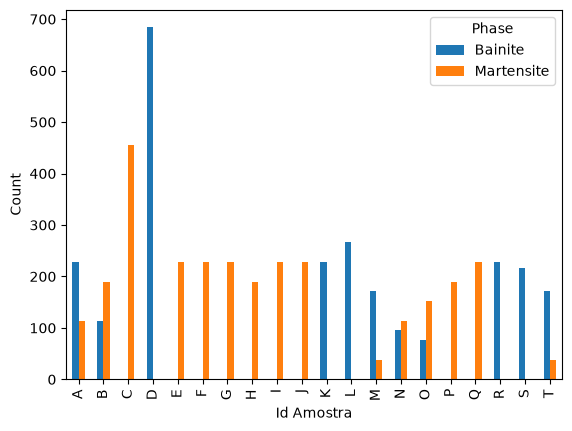

Amostras que possuem ambas as fases: ['A', 'B', 'M', 'N', 'O', 'T']


In [20]:
sns.countplot(df, x='Phase', hue='Phase', palette='pastel')
by_sample = pd.crosstab(df.SampleIDHarm, df.Phase)
by_sample.plot(kind='bar', stacked=False)
plt.ylabel('Count')
plt.xlabel('Id Amostra')
plt.show()

both_sample = by_sample[(by_sample['Bainite'] > 0) & (by_sample['Martensite'] > 0)].index.tolist()
print(f'Amostras que possuem ambas as fases: {both_sample}')

### Estrutura do Dataset

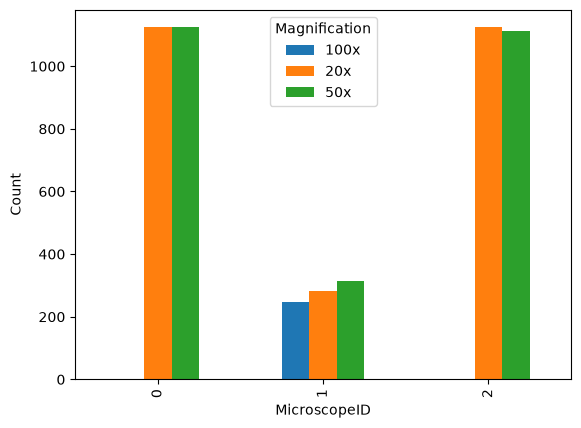

In [26]:
id_by_magnification = pd.crosstab(df.MicroscopeID, df.Magnification)
id_by_magnification.plot(kind='bar', stacked=False)
plt.ylabel('Count')
plt.show()
